In [1]:
import numpy as np
import matplotlib.pyplot as plt

from src.measurement_scenario import MeasurementScenario
from src.hvm import HVM
from src.signaling import Signaling

Scenario:


In [2]:
X = [i for i in range(4)]
M = [[0,2],[0,3],[1,2],[1,3]]
O = [0,1]
chsh = MeasurementScenario(X, M, O)

Quanmtum realization as empirical model

In [3]:
meas = np.zeros((4,2,4,4))# shape = number mesurements, number of outcomes, dimension of state (d x d)
N = 1/np.sqrt(2)
# for i in range(5):
#     vec = N * np.array([np.cos(4*np.pi*i/5), np.sin(4*np.pi*i/5), np.sqrt(np.cos(np.pi/5))])
#     meas[i][1] = np.outer(vec, vec)
#     meas[i][0] = np.eye(3) - meas[i][1]

psi = N*np.array([1,0,0,1])
rho = np.outer(psi, psi.conj())

In [4]:
empirical_model = chsh.quantum_realization(rho, meas)
empirical_model

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [5]:
CSHS = 0
C = np.zeros(empirical_model.shape)
for i in range(5):
    KCBS += empirical_model[1+4*i]
    C[1+4*i] = 1

# Quantum Bound (Lovasz): np.sqrt(5) = 2.23606797749979
KCBS 

2.2360679774997894

In [6]:
hvm = HVM(kcbs)
hvm.V_polytope()
result = hvm.Contextual_Ineq(C, verbose=False)
result["HVM_bound"]

2.0

Contextual Fraction

In [7]:
result = kcbs.compute_NCF(solver='MOSEK', verbose=False)
CF = result['CF']
CF

0.4721359549995786

In [18]:
result_hvm = hvm.compute_NCF(solver='MOSEK', verbose=False)
result_hvm['CF']

-8.828493491819245e-13

In [19]:
signal = Signaling(kcbs)
signal.V_polytope()
result_signal = signal.compute_NCF(solver='MOSEK', verbose=False)
result_signal['CF']

-7.41606775989112e-12

Contextual Fraction Bound

In [9]:
x = np.linspace(0, 0.99, 10000)
y = np.linspace(0, 0.99, 10000)
xv, yv = np.meshgrid(x, y)

CF_bound = kcbs.CF_bound(xv, yv)
Z = np.ma.masked_greater(CF_bound, CF)

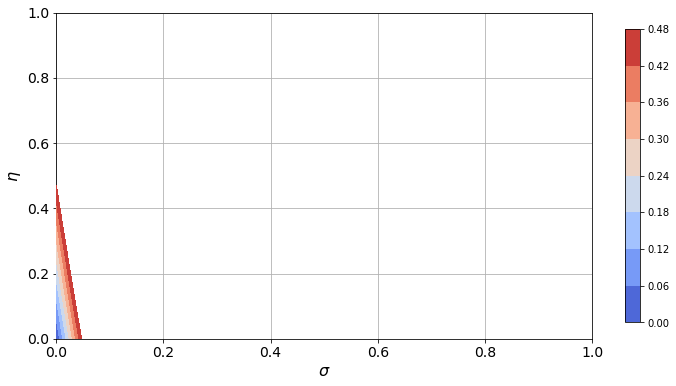

In [10]:
fig, ax = plt.subplots(figsize=(12,6))

cs = ax.contourf(xv, yv, Z, zorder=5, cmap=plt.cm.coolwarm)
ax.xaxis.grid(True, zorder=0)
plt.xticks(fontsize=14, rotation=0)
ax.yaxis.grid(True, zorder=0)
plt.yticks(fontsize=14, rotation=0)
plt.xlabel('$\sigma$', fontsize=16)
plt.ylabel('$\eta$', fontsize=16)
plt.xlim(0, 1)
plt.ylim(0, 1)
fig.colorbar(cs, ax=ax, shrink=0.9)

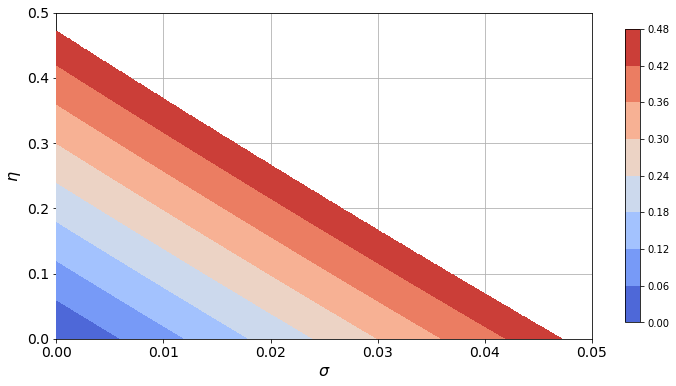

In [11]:
fig, ax = plt.subplots(figsize=(12,6))

cs = ax.contourf(xv, yv, Z, zorder=5, cmap=plt.cm.coolwarm)
ax.xaxis.grid(True, zorder=0)
plt.xticks(fontsize=14, rotation=0)
ax.yaxis.grid(True, zorder=0)
plt.yticks(fontsize=14, rotation=0)
plt.xlabel('$\sigma$', fontsize=16)
plt.ylabel('$\eta$', fontsize=16)
plt.xlim(0, 0.05)
plt.ylim(0, 0.5)
fig.colorbar(cs, ax=ax, shrink=0.9)